In [6]:
import sys
from pathlib import Path

# Sube desde el directorio actual hasta encontrar la raíz del proyecto
# (la que contiene la carpeta 'src'). Funciona en cualquier SO/entorno.
project_root = Path.cwd().resolve()
while not (project_root / "src").is_dir() and project_root != project_root.parent:
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from IPython.display import Image, display

from src.graph.workflow import financial_app


In [7]:
import requests
from langchain_core.runnables.graph import MermaidDrawMethod

# mermaid.ink cae o queda bloqueada con frecuencia (ConnectTimeout), y
# `draw_mermaid_png()` no tiene alternativa: levanta ValueError y el notebook
# se queda sin diagrama. La cadena de abajo prueba varios renderizadores y solo
# falla si NINGUNO responde; en ese caso deja el .mmd en disco, que es texto y
# se puede pegar en https://mermaid.live a mano.
#
# kroki.io renderiza el MISMO codigo Mermaid por POST (sin limite de longitud
# de URL, a diferencia del GET con base64 de mermaid.ink).

TIEMPO_ESPERA = 20


def _via_mermaid_ink(app) -> bytes:
    return app.get_graph().draw_mermaid_png(
        draw_method=MermaidDrawMethod.API, max_retries=0
    )


def _via_kroki(app) -> bytes:
    fuente = app.get_graph().draw_mermaid()
    respuesta = requests.post(
        "https://kroki.io/mermaid/png",
        data=fuente.encode("utf-8"),
        headers={"Content-Type": "text/plain"},
        timeout=TIEMPO_ESPERA,
    )
    respuesta.raise_for_status()
    return respuesta.content


def _via_pyppeteer(app) -> bytes:
    # Render local en un Chromium sin cabeza. Requiere `pip install pyppeteer`
    # y descarga el navegador la primera vez (~150 MB).
    return app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)


RENDERIZADORES = (
    ("mermaid.ink", _via_mermaid_ink),
    ("kroki.io", _via_kroki),
    ("pyppeteer (local)", _via_pyppeteer),
)


def renderizar_grafo(app, destino=None) -> bytes:
    """Devuelve el PNG del grafo probando los renderizadores por orden.

    Si `destino` se indica, guarda ahi el PNG. Cuando todos fallan, vuelca el
    codigo Mermaid junto a `destino` (o en el directorio actual) y levanta la
    excepcion: una ausencia declarada, nunca un diagrama inventado.
    """
    fallos = []
    for nombre, renderizador in RENDERIZADORES:
        try:
            png = renderizador(app)
        except Exception as exc:  # se declara el fallo y se sigue probando
            fallos.append(f"{nombre}: {type(exc).__name__}: {exc}")
            print(f"[grafo] {nombre} no disponible ({type(exc).__name__}).")
            continue

        print(f"[grafo] renderizado con {nombre} ({len(png)} bytes).")
        if destino is not None:
            destino = Path(destino)
            destino.parent.mkdir(parents=True, exist_ok=True)
            destino.write_bytes(png)
            print(f"[grafo] guardado en {destino}")
        return png

    mmd = Path(destino).with_suffix(".mmd") if destino else Path("grafo.mmd")
    mmd.write_text(app.get_graph().draw_mermaid(), encoding="utf-8")
    raise RuntimeError(
        "Ningun renderizador de Mermaid respondio -> "
        + " | ".join(fallos)
        + f". El codigo Mermaid esta en {mmd}: pegalo en https://mermaid.live"
    )


[grafo] renderizado con mermaid.ink (29834 bytes).
[grafo] guardado en C:\Users\cterr\Documents\10_Multi_Agent_Financiero\output\grafo.png


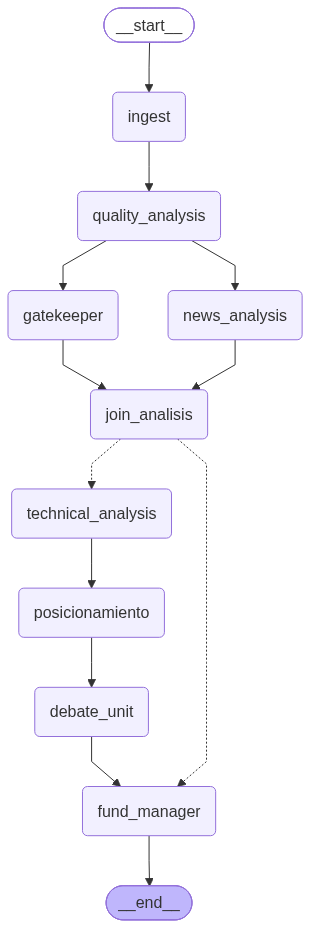

In [8]:
# draw_mermaid_png() devuelve bytes crudos de PNG; hay que envolverlos en
# Image() para que el notebook los renderice como imagen (no como texto).
png = renderizar_grafo(financial_app, destino=project_root / "output" / "grafo.png")
display(Image(png))
